<a href="https://colab.research.google.com/github/2023atharvvichare/Machine-Learning/blob/main/ML_Experiment_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
data = {
    'X1': [0, 0, 1, 1],
    'X2': [0, 1, 0, 1],
    'Y':  [0, 0, 0, 1]
}

df = pd.DataFrame(data)
print("Training Data:\n", df)


Training Data:
    X1  X2  Y
0   0   0  0
1   0   1  0
2   1   0  0
3   1   1  1


In [3]:
# Convert data to numpy arrays
X = df[['X1', 'X2']].values
Y = df['Y'].values

# Initialize weights and learning rate
weights = np.zeros(X.shape[1])
bias = 0
eta = 0.1  # learning rate

print("Initial Weights:", weights)
print("Initial Bias:", bias)


Initial Weights: [0. 0.]
Initial Bias: 0


In [4]:
for i in range(len(X)):
    x = X[i]
    y = Y[i]

    # Hebbian weight update
    weights = weights + eta * x * y
    bias = bias + eta * y

    print(f"Iteration {i+1}: x={x}, y={y}, Updated Weights={weights}, Bias={bias}")


Iteration 1: x=[0 0], y=0, Updated Weights=[0. 0.], Bias=0.0
Iteration 2: x=[0 1], y=0, Updated Weights=[0. 0.], Bias=0.0
Iteration 3: x=[1 0], y=0, Updated Weights=[0. 0.], Bias=0.0
Iteration 4: x=[1 1], y=1, Updated Weights=[0.1 0.1], Bias=0.1


In [5]:
print("\nFinal Learned Weights:", weights)
print("Final Bias:", bias)



Final Learned Weights: [0.1 0.1]
Final Bias: 0.1


In [6]:
def hebbian_predict(x, weights, bias):
    total = np.dot(x, weights) + bias
    return 1 if total >= 0.5 else 0  # simple threshold

# Test all patterns
predictions = [hebbian_predict(x, weights, bias) for x in X]
df['Predicted'] = predictions
print("\nPredictions:\n", df)



Predictions:
    X1  X2  Y  Predicted
0   0   0  0          0
1   0   1  0          0
2   1   0  0          0
3   1   1  1          0


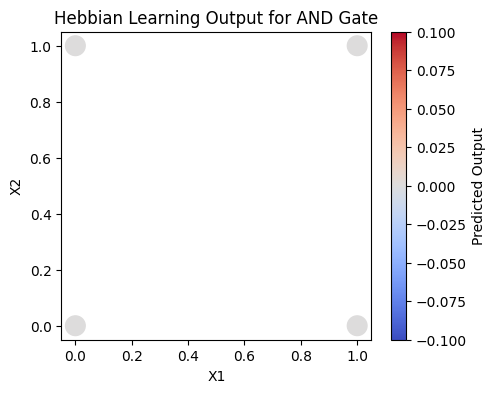

In [7]:
plt.figure(figsize=(5,4))
plt.scatter(df['X1'], df['X2'], c=df['Predicted'], cmap='coolwarm', s=200)
plt.title("Hebbian Learning Output for AND Gate")
plt.xlabel("X1")
plt.ylabel("X2")
plt.colorbar(label='Predicted Output')
plt.show()


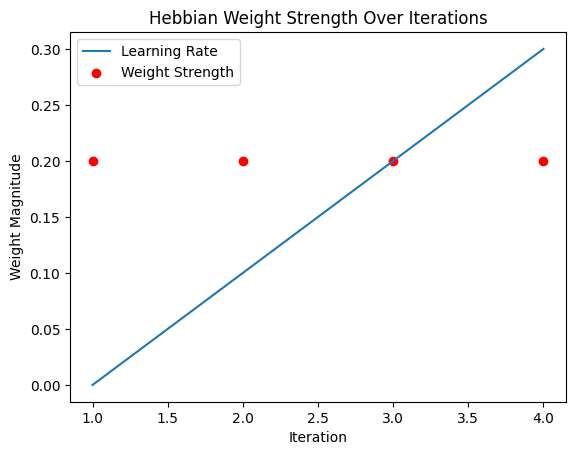

In [8]:
# Visualize weight updates per epoch
plt.plot(range(1, len(X)+1), [0.1*i for i in range(len(X))], label="Learning Rate")
plt.scatter(range(1, len(X)+1), [sum(weights)]*len(X), color='red', label="Weight Strength")
plt.title("Hebbian Weight Strength Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Weight Magnitude")
plt.legend()
plt.show()
